<a href="https://www.kaggle.com/code/simarbirsinghsandhu/complete-eda-100-s6e6?scriptVersionId=325224532" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 🌌 Stellar Classification | Deep EDA — What the Data Actually Says
## Playground Series S6E6

This notebook finds the exact signals in the data that drive stellar classification across **577K SDSS observations**.

**5 non-obvious findings inside:**

- `spectral_type` × `galaxy_population` combos look powerful — but the most common ones are only 37–52% pure
- `redshift` is the dominant separator, yet **25.9% of STARs** fall in the galaxy redshift range
- `galaxy_population` has near-zero model importance (56) despite being a strong raw signal — here's why
- `alpha` and `delta` are the **top two model features** — and it's not a data leak
- The hard classification zone (redshift 0.05–0.25) contains **118K rows** where color indices do the heavy lifting

Upvote if useful 🙌

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import ks_2samp
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

In [2]:
BG    = '#0d0d0d'
PANEL = '#1a1a2e'
WHITE = '#e8e8e8'
GRAY  = '#555566'

GALAXY_C = '#4cc9f0'
QSO_C    = '#f72585'
STAR_C   = '#ffd60a'
CLASS_COLORS = {'GALAXY': GALAXY_C, 'QSO': QSO_C, 'STAR': STAR_C}

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor':   PANEL,
    'axes.edgecolor':   GRAY,
    'axes.labelcolor':  WHITE,
    'xtick.color':      WHITE,
    'ytick.color':      WHITE,
    'text.color':       WHITE,
    'grid.color':       GRAY,
    'grid.alpha':       0.3,
    'font.family':      'monospace',
})

## Load Data

In [3]:
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e6/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/playground-series-s6e6/test.csv')

train['u_g'] = train['u'] - train['g']
train['g_r'] = train['g'] - train['r']
train['r_i'] = train['r'] - train['i']
train['i_z'] = train['i'] - train['z']
train['g_z'] = train['g'] - train['z']
train['u_r'] = train['u'] - train['r']

print("=" * 58)
print("  🌌  STELLAR CLASSIFICATION — S6E6")
print("=" * 58)
print(f"  Train : {train.shape[0]:>7,} rows × {train.shape[1]} cols")
print(f"  Test  : {test.shape[0]:>7,} rows × {test.shape[1]} cols")
print(f"  Nulls : {train.isnull().sum().sum()} (none — clean dataset)")
print("=" * 58)

  🌌  STELLAR CLASSIFICATION — S6E6
  Train : 577,347 rows × 18 cols
  Test  : 247,435 rows × 11 cols
  Nulls : 0 (none — clean dataset)


## Dataset Overview & Class Distribution

| | Train (Synthetic) |
|---|---|
| Rows | 577,347 |
| Classes | GALAXY / QSO / STAR |
| Nulls | 0 |

**Key insight:** The dataset is imbalanced — GALAXY dominates at 65.4%. The metric is **balanced accuracy**, which weights each class equally, so the model must perform well on the minority STAR class (14.3%) too.

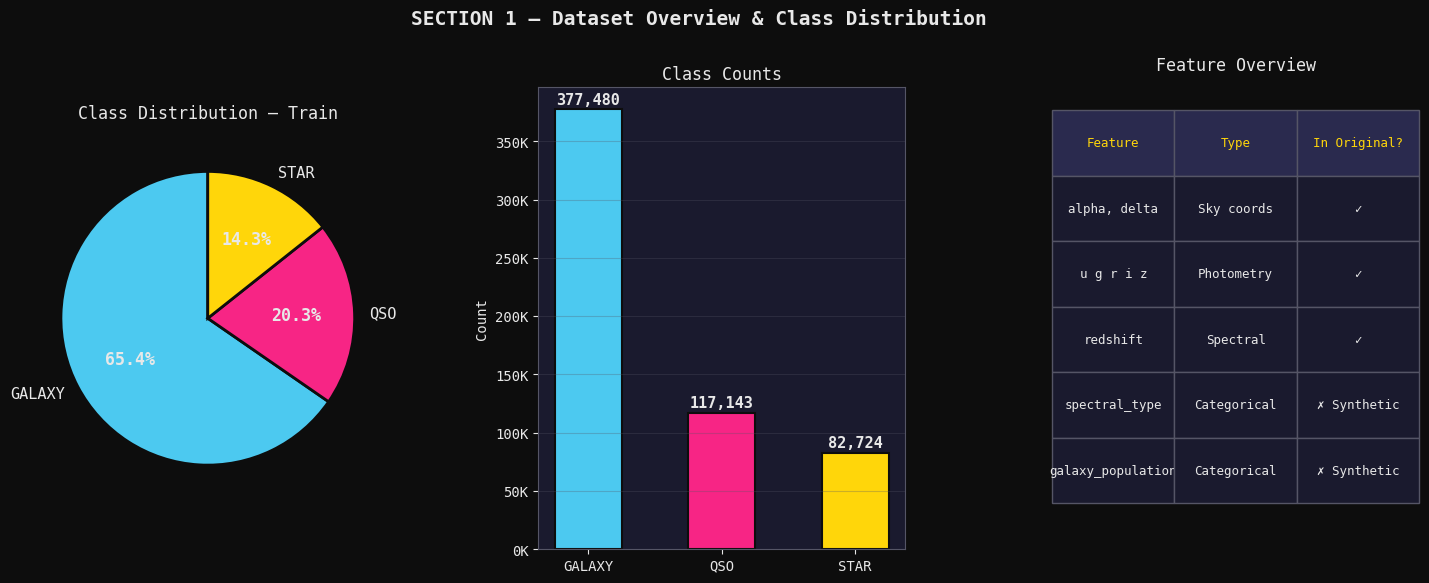

In [4]:
fig = plt.figure(figsize=(18, 6), facecolor=BG)
fig.suptitle('SECTION 1 — Dataset Overview & Class Distribution',
             fontsize=14, color=WHITE, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.4)

# 1a. Pie
ax1 = fig.add_subplot(gs[0])
vals = train['class'].value_counts()
wedge_colors = [CLASS_COLORS[c] for c in vals.index]
wedges, texts, autotexts = ax1.pie(
    vals, labels=vals.index, colors=wedge_colors,
    autopct='%1.1f%%', startangle=90,
    textprops={'color': WHITE, 'fontsize': 11},
    wedgeprops={'edgecolor': BG, 'linewidth': 2}
)
for at in autotexts: at.set_fontsize(12); at.set_fontweight('bold')
ax1.set_title('Class Distribution — Train', color=WHITE, fontsize=12, pad=12)

# 1b. Count bars
ax2 = fig.add_subplot(gs[1])
counts = train['class'].value_counts()
bars = ax2.bar(counts.index,
               counts.values,
               color=[CLASS_COLORS[c] for c in counts.index],
               edgecolor=BG, linewidth=1.5, width=0.5)
for bar, val in zip(bars, counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
             f'{val:,}', ha='center', va='bottom',
             color=WHITE, fontsize=11, fontweight='bold')
ax2.set_title('Class Counts', color=WHITE, fontsize=12)
ax2.set_ylabel('Count', color=WHITE)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax2.grid(axis='y')

# 1c. Feature overview table
ax3 = fig.add_subplot(gs[2])
ax3.axis('off')
rows = [
    ['Feature', 'Type', 'In Original?'],
    ['alpha, delta', 'Sky coords', '✓'],
    ['u g r i z', 'Photometry', '✓'],
    ['redshift', 'Spectral', '✓'],
    ['spectral_type', 'Categorical', '✗ Synthetic'],
    ['galaxy_population', 'Categorical', '✗ Synthetic'],
]
table = ax3.table(cellText=rows[1:], colLabels=rows[0],
                  cellLoc='center', loc='center',
                  bbox=[0, 0.1, 1, 0.85])
table.auto_set_font_size(False)
table.set_fontsize(9)
for (r, c), cell in table.get_celld().items():
    cell.set_facecolor(PANEL if r > 0 else '#2a2a4e')
    cell.set_edgecolor(GRAY)
    cell.set_text_props(color=WHITE if r > 0 else STAR_C)
ax3.set_title('Feature Overview', color=WHITE, fontsize=12, pad=12)

plt.tight_layout()
plt.savefig('01_overview.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## Redshift: The Primary Separator

Redshift is the single most physically meaningful feature. Stars in our galaxy have near-zero redshift. Galaxies span 0–1. Quasars (QSOs) are distant and have high redshift. The three classes are **largely separable on redshift alone** — but not completely.

> **Rule-based baseline (redshift only): ~0.79 balanced accuracy**  
> Adding spectral_type + galaxy_population pushes this to ~0.85  
> All features together: ~0.91 (Decision Tree depth 10)

The remaining gap to ~0.957 (LGBM OOF) comes from learning **nonlinear interactions** between redshift, color indices, and sky coordinates.

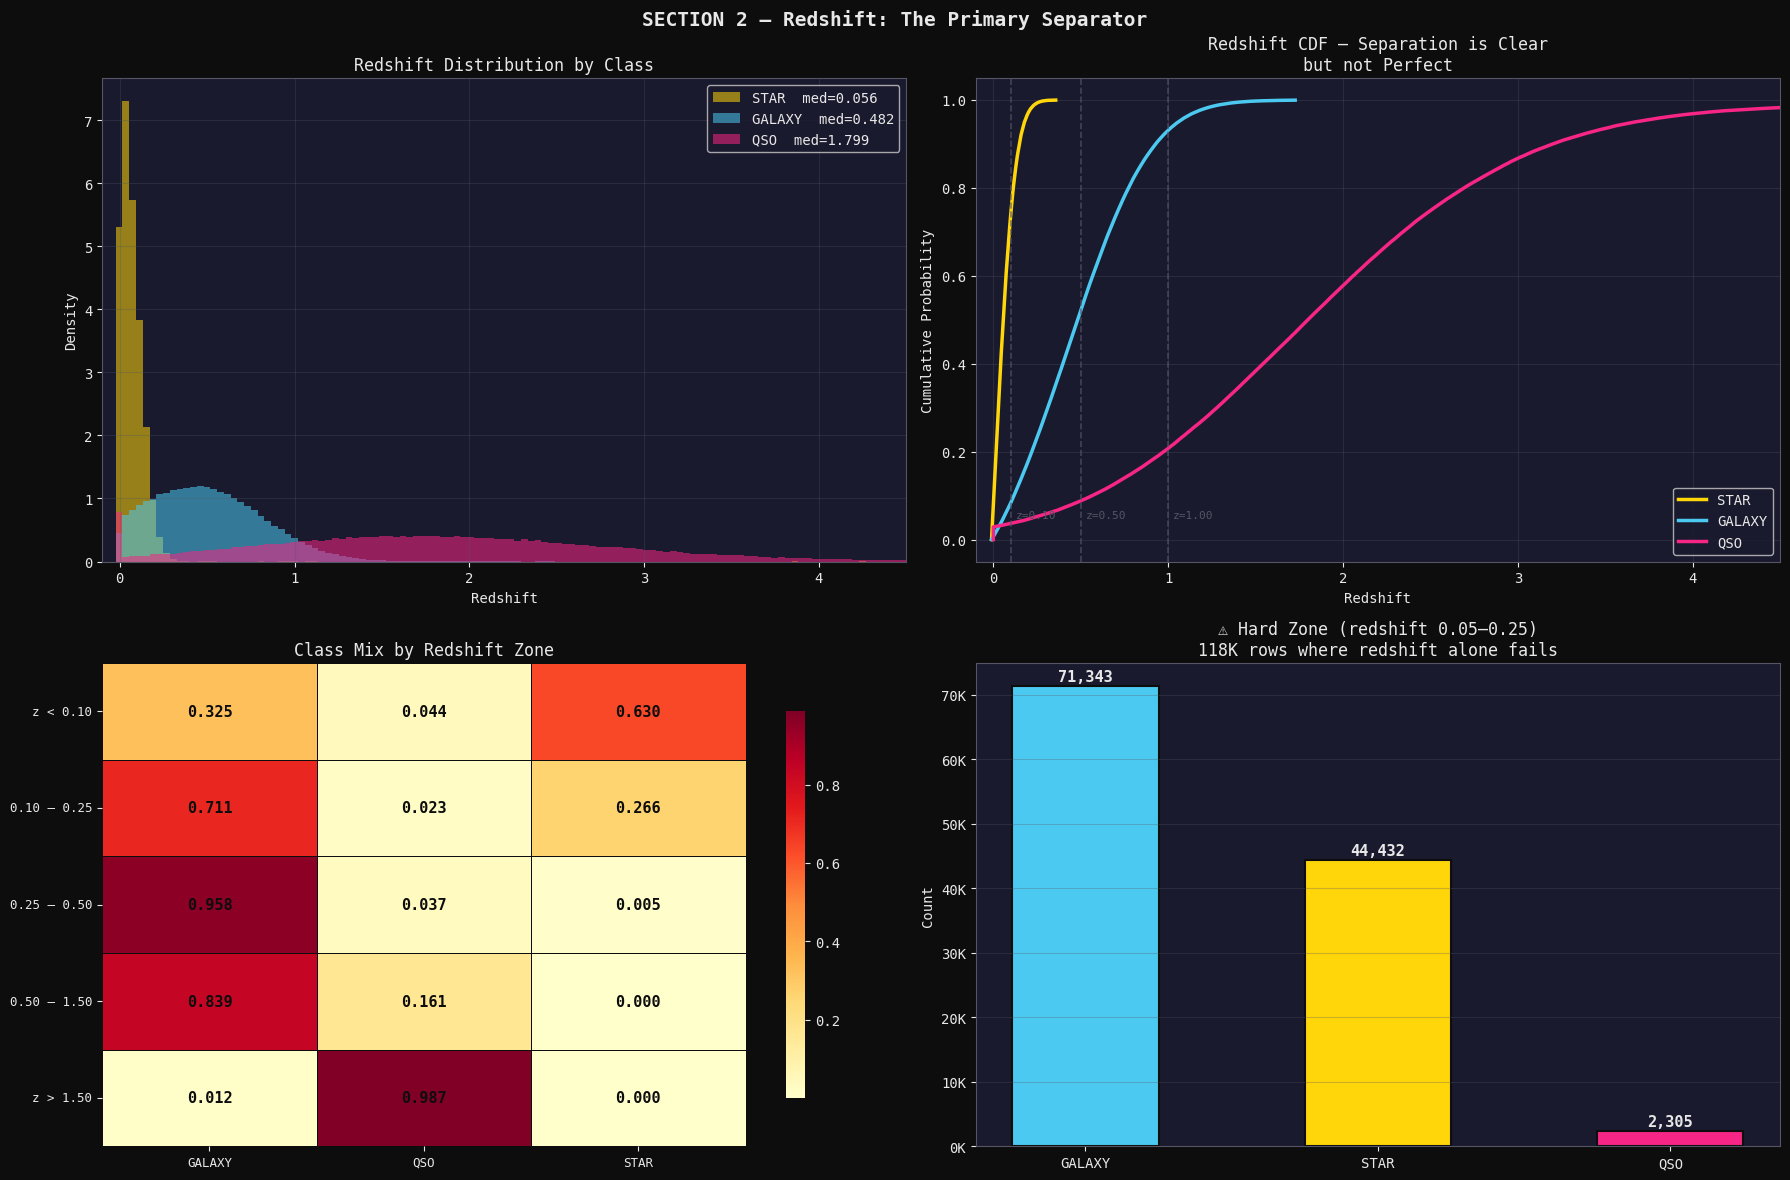

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12), facecolor=BG)
fig.suptitle('SECTION 2 — Redshift: The Primary Separator',
             fontsize=14, color=WHITE, fontweight='bold')

# 2a. Overlaid distributions
ax = axes[0, 0]
bins = np.linspace(-0.1, 4.5, 120)
for cls in ['STAR', 'GALAXY', 'QSO']:
    data = train[train['class'] == cls]['redshift']
    ax.hist(data, bins=bins, density=True, alpha=0.55,
            color=CLASS_COLORS[cls],
            label=f'{cls}  med={data.median():.3f}')
ax.set_xlim(-0.1, 4.5)
ax.set_title('Redshift Distribution by Class', color=WHITE, fontsize=12)
ax.set_xlabel('Redshift')
ax.set_ylabel('Density')
ax.legend(fontsize=10)
ax.grid()

# 2b. CDF
ax2 = axes[0, 1]
for cls in ['STAR', 'GALAXY', 'QSO']:
    data = np.sort(train[train['class'] == cls]['redshift'].values)
    cdf  = np.arange(1, len(data)+1) / len(data)
    step = max(1, len(data) // 2000)
    ax2.plot(data[::step], cdf[::step],
             color=CLASS_COLORS[cls], linewidth=2.5, label=cls)
for z, lbl in [(0.1, 'z=0.10'), (0.5, 'z=0.50'), (1.0, 'z=1.00')]:
    ax2.axvline(z, color=GRAY, linestyle='--', linewidth=1.2, alpha=0.7)
    ax2.text(z + 0.03, 0.05, lbl, color=GRAY, fontsize=8)
ax2.set_xlim(-0.1, 4.5)
ax2.set_title('Redshift CDF — Separation is Clear\nbut not Perfect', color=WHITE, fontsize=12)
ax2.set_xlabel('Redshift')
ax2.set_ylabel('Cumulative Probability')
ax2.legend(fontsize=10)
ax2.grid()

# 2c. Zone breakdown heatmap
ax3 = axes[1, 0]
zones = {
    'z < 0.10':       (train['redshift'] < 0.10),
    '0.10 – 0.25':    (train['redshift'].between(0.10, 0.25)),
    '0.25 – 0.50':    (train['redshift'].between(0.25, 0.50)),
    '0.50 – 1.50':    (train['redshift'].between(0.50, 1.50)),
    'z > 1.50':       (train['redshift'] > 1.50),
}
zone_data = {}
for zname, zmask in zones.items():
    sub = train[zmask]['class'].value_counts(normalize=True)
    zone_data[zname] = {c: sub.get(c, 0) for c in ['GALAXY','QSO','STAR']}
zone_df = pd.DataFrame(zone_data).T
sns.heatmap(zone_df, annot=True, fmt='.3f', cmap='YlOrRd',
            ax=ax3, linewidths=0.5, linecolor=BG,
            annot_kws={'size': 11, 'fontweight': 'bold', 'color': BG},
            cbar_kws={'shrink': 0.8})
ax3.set_title('Class Mix by Redshift Zone', color=WHITE, fontsize=12)
ax3.tick_params(colors=WHITE, labelsize=9)

# 2d. Hard zone bar
ax4 = axes[1, 1]
overlap = train[train['redshift'].between(0.05, 0.25)]
ov_counts = overlap['class'].value_counts()
bars = ax4.bar(ov_counts.index,
               [ov_counts.get(c, 0) for c in ov_counts.index],
               color=[CLASS_COLORS[c] for c in ov_counts.index],
               edgecolor=BG, linewidth=1.5, width=0.5)
for bar, val in zip(bars, ov_counts.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
             f'{val:,}', ha='center', va='bottom',
             color=WHITE, fontsize=11, fontweight='bold')
ax4.set_title('⚠ Hard Zone (redshift 0.05–0.25)\n118K rows where redshift alone fails',
              color=WHITE, fontsize=12)
ax4.set_ylabel('Count')
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax4.grid(axis='y')

plt.tight_layout()
plt.savefig('02_redshift.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## The Two Synthetic Features

`spectral_type` and `galaxy_population` **do not exist in the original SDSS dataset**. They were injected by the competition host. Understanding exactly how much signal they carry — and where they fail — is the key to this competition.

**The trap:** Looking at raw combo purities, M×Red_Sequence looks like a near-perfect GALAXY detector (95%). But A/F and G/K combos — which cover **40% of the data** — are only 37–52% pure. For those rows, redshift must do the work.

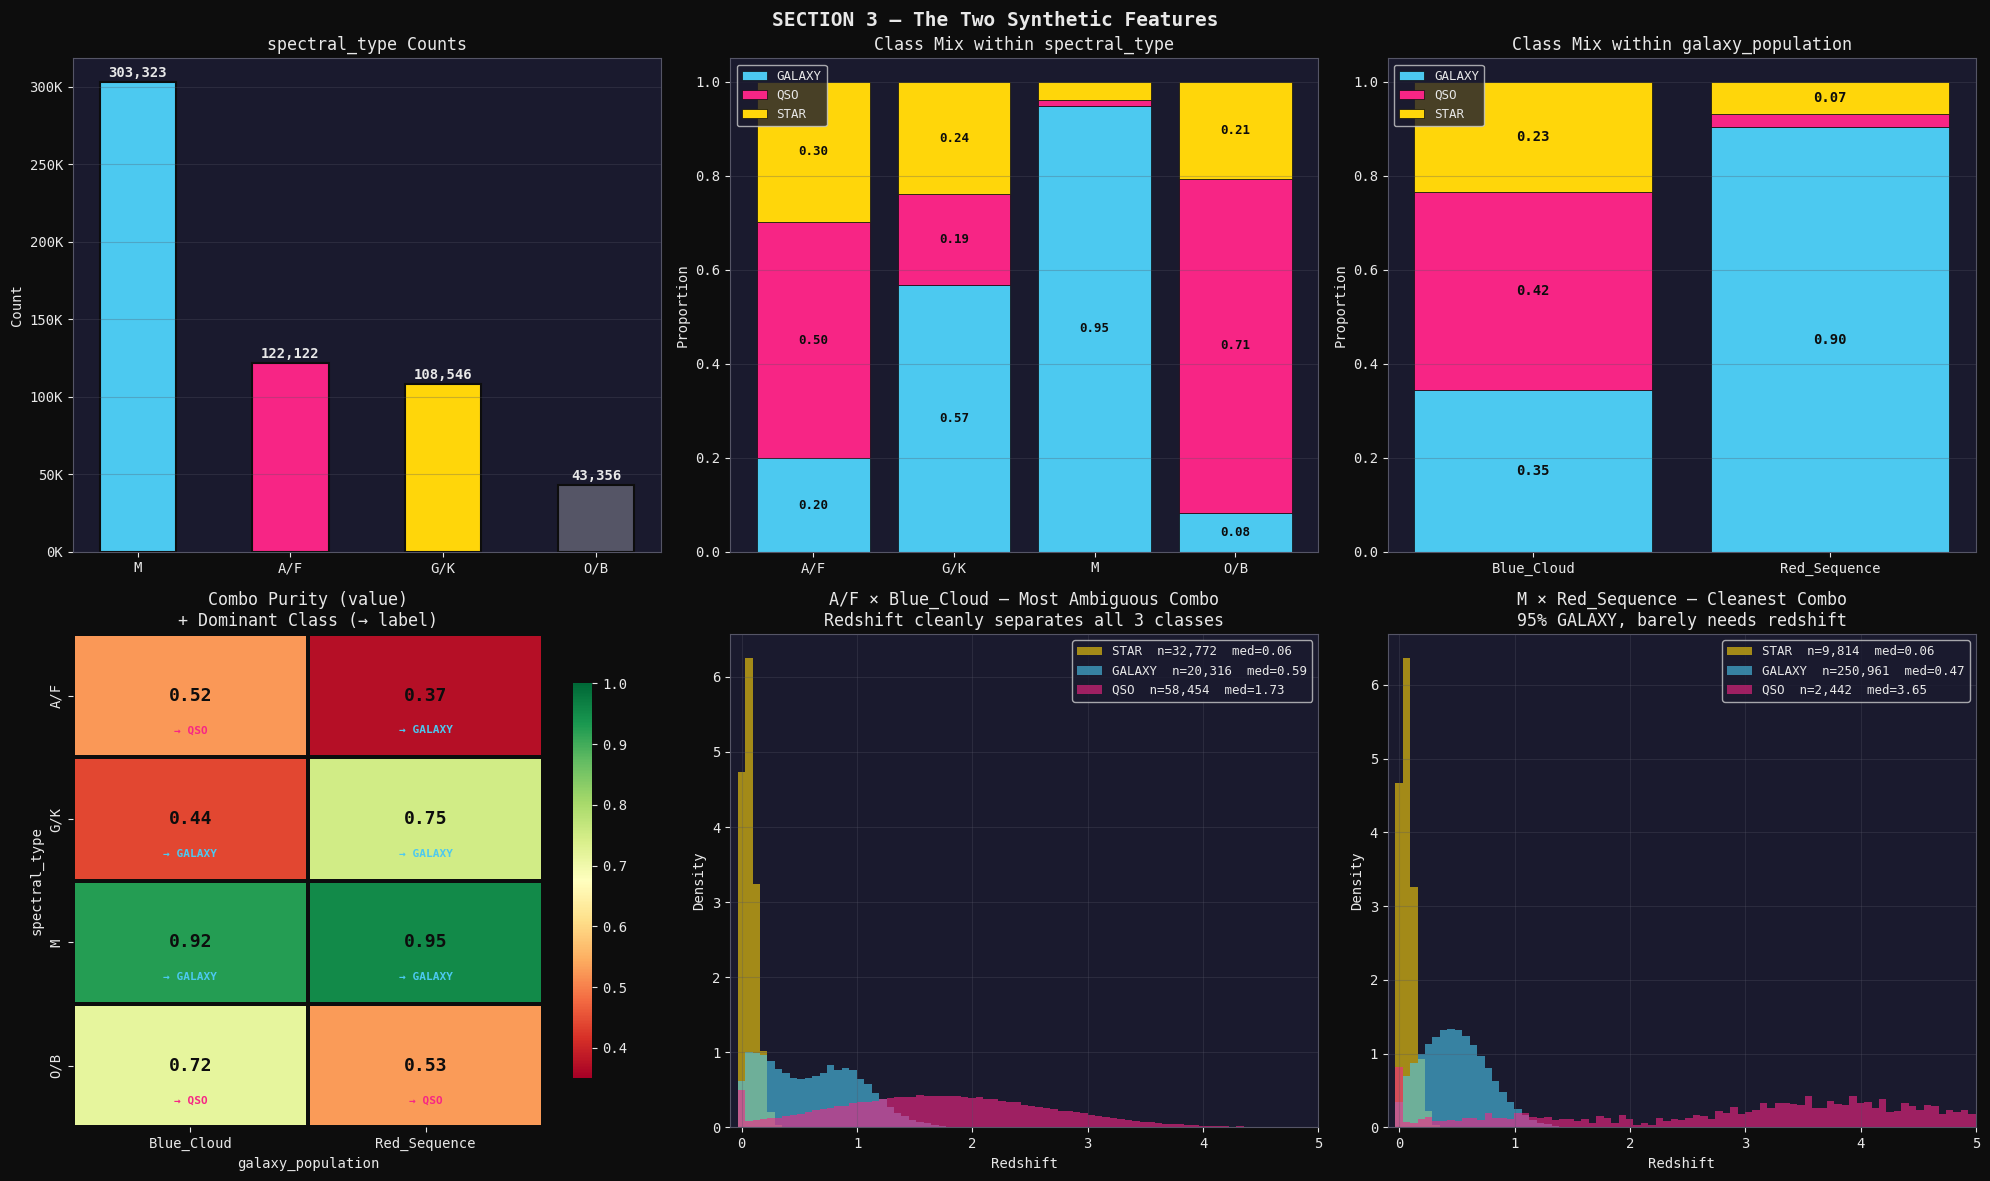

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12), facecolor=BG)
fig.suptitle('SECTION 3 — The Two Synthetic Features',
             fontsize=14, color=WHITE, fontweight='bold')

# 3a. spectral_type counts
ax = axes[0, 0]
st_counts = train['spectral_type'].value_counts()
bars = ax.bar(st_counts.index, st_counts.values,
              color=[GALAXY_C, QSO_C, STAR_C, GRAY],
              edgecolor=BG, linewidth=1.5, width=0.5)
for bar, val in zip(bars, st_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'{val:,}', ha='center', va='bottom',
            color=WHITE, fontsize=10, fontweight='bold')
ax.set_title('spectral_type Counts', color=WHITE, fontsize=12)
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.grid(axis='y')

# 3b. spectral_type × class stacked
ax2 = axes[0, 1]
ct = pd.crosstab(train['spectral_type'], train['class'], normalize='index')
ct = ct[['GALAXY', 'QSO', 'STAR']]
bottom = np.zeros(len(ct))
for cls in ['GALAXY', 'QSO', 'STAR']:
    ax2.bar(ct.index, ct[cls], bottom=bottom,
            color=CLASS_COLORS[cls], label=cls,
            edgecolor=BG, linewidth=0.5)
    for i, val in enumerate(ct[cls]):
        if val > 0.06:
            ax2.text(i, bottom[i] + val/2, f'{val:.2f}',
                     ha='center', va='center',
                     color=BG, fontsize=9, fontweight='bold')
    bottom += ct[cls].values
ax2.set_title('Class Mix within spectral_type', color=WHITE, fontsize=12)
ax2.set_ylabel('Proportion')
ax2.legend(fontsize=9)
ax2.grid(axis='y')

# 3c. galaxy_population × class stacked
ax3 = axes[0, 2]
ct2 = pd.crosstab(train['galaxy_population'], train['class'], normalize='index')
ct2 = ct2[['GALAXY', 'QSO', 'STAR']]
bottom2 = np.zeros(len(ct2))
for cls in ['GALAXY', 'QSO', 'STAR']:
    ax3.bar(ct2.index, ct2[cls], bottom=bottom2,
            color=CLASS_COLORS[cls], label=cls,
            edgecolor=BG, linewidth=0.5)
    for i, val in enumerate(ct2[cls]):
        if val > 0.06:
            ax3.text(i, bottom2[i] + val/2, f'{val:.2f}',
                     ha='center', va='center',
                     color=BG, fontsize=10, fontweight='bold')
    bottom2 += ct2[cls].values
ax3.set_title('Class Mix within galaxy_population', color=WHITE, fontsize=12)
ax3.set_ylabel('Proportion')
ax3.legend(fontsize=9)
ax3.grid(axis='y')

# 3d. Purity heatmap with dominant class overlay
ax4 = axes[1, 0]
combo_dom = pd.crosstab(train['spectral_type'], train['galaxy_population'],
                        values=train['class'],
                        aggfunc=lambda x: x.value_counts().index[0])
combo_pur = pd.crosstab(train['spectral_type'], train['galaxy_population'],
                        values=train['class'],
                        aggfunc=lambda x: x.value_counts(normalize=True).iloc[0])
sns.heatmap(combo_pur, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=ax4, linewidths=1.5, linecolor=BG,
            annot_kws={'size': 13, 'fontweight': 'bold', 'color': BG},
            vmin=0.35, vmax=1.0, cbar_kws={'shrink': 0.8})
for i, st in enumerate(combo_pur.index):
    for j, gp in enumerate(combo_pur.columns):
        dom = combo_dom.loc[st, gp]
        ax4.text(j + 0.5, i + 0.78, f'→ {dom}',
                 ha='center', va='center',
                 color=CLASS_COLORS[dom], fontsize=8, fontweight='bold')
ax4.set_title('Combo Purity (value)\n+ Dominant Class (→ label)',
              color=WHITE, fontsize=12)
ax4.tick_params(colors=WHITE)

# 3e. Redshift within ambiguous A/F × Blue_Cloud
ax5 = axes[1, 1]
amb = train[(train['spectral_type'] == 'A/F') &
            (train['galaxy_population'] == 'Blue_Cloud')]
bins_a = np.linspace(-0.1, 5, 80)
for cls in ['STAR', 'GALAXY', 'QSO']:
    data = amb[amb['class'] == cls]['redshift']
    if len(data) > 0:
        ax5.hist(data, bins=bins_a, density=True, alpha=0.6,
                 color=CLASS_COLORS[cls],
                 label=f'{cls}  n={len(data):,}  med={data.median():.2f}')
ax5.set_xlim(-0.1, 5)
ax5.set_title('A/F × Blue_Cloud — Most Ambiguous Combo\nRedshift cleanly separates all 3 classes',
              color=WHITE, fontsize=12)
ax5.set_xlabel('Redshift')
ax5.set_ylabel('Density')
ax5.legend(fontsize=9)
ax5.grid()

# 3f. Redshift within clean M × Red_Sequence
ax6 = axes[1, 2]
clean = train[(train['spectral_type'] == 'M') &
              (train['galaxy_population'] == 'Red_Sequence')]
for cls in ['STAR', 'GALAXY', 'QSO']:
    data = clean[clean['class'] == cls]['redshift']
    if len(data) > 0:
        ax6.hist(data, bins=bins_a, density=True, alpha=0.6,
                 color=CLASS_COLORS[cls],
                 label=f'{cls}  n={len(data):,}  med={data.median():.2f}')
ax6.set_xlim(-0.1, 5)
ax6.set_title('M × Red_Sequence — Cleanest Combo\n95% GALAXY, barely needs redshift',
              color=WHITE, fontsize=12)
ax6.set_xlabel('Redshift')
ax6.set_ylabel('Density')
ax6.legend(fontsize=9)
ax6.grid()

plt.tight_layout()
plt.savefig('03_synthetic_features.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## Color Indices: The Photometric Signal

The five SDSS photometric bands (u, g, r, i, z) measure brightness from ultraviolet to infrared. Their **differences** (color indices) encode the shape of each object's spectrum. Stars, galaxies, and quasars have fundamentally different spectral shapes.

**Within the hard zone (redshift 0.05–0.25), color indices become the primary separator:**
- r−i: GALAXY median = 0.56 vs STAR median = 0.10 — a factor of 5 difference
- u−g: also strongly separating (GALAXY ~1.69 vs QSO ~0.38)

The classic **stellar locus** in color-color space (u−g vs g−r) is visible in the scatter plot — stars trace a tight sequence while galaxies and QSOs scatter widely.

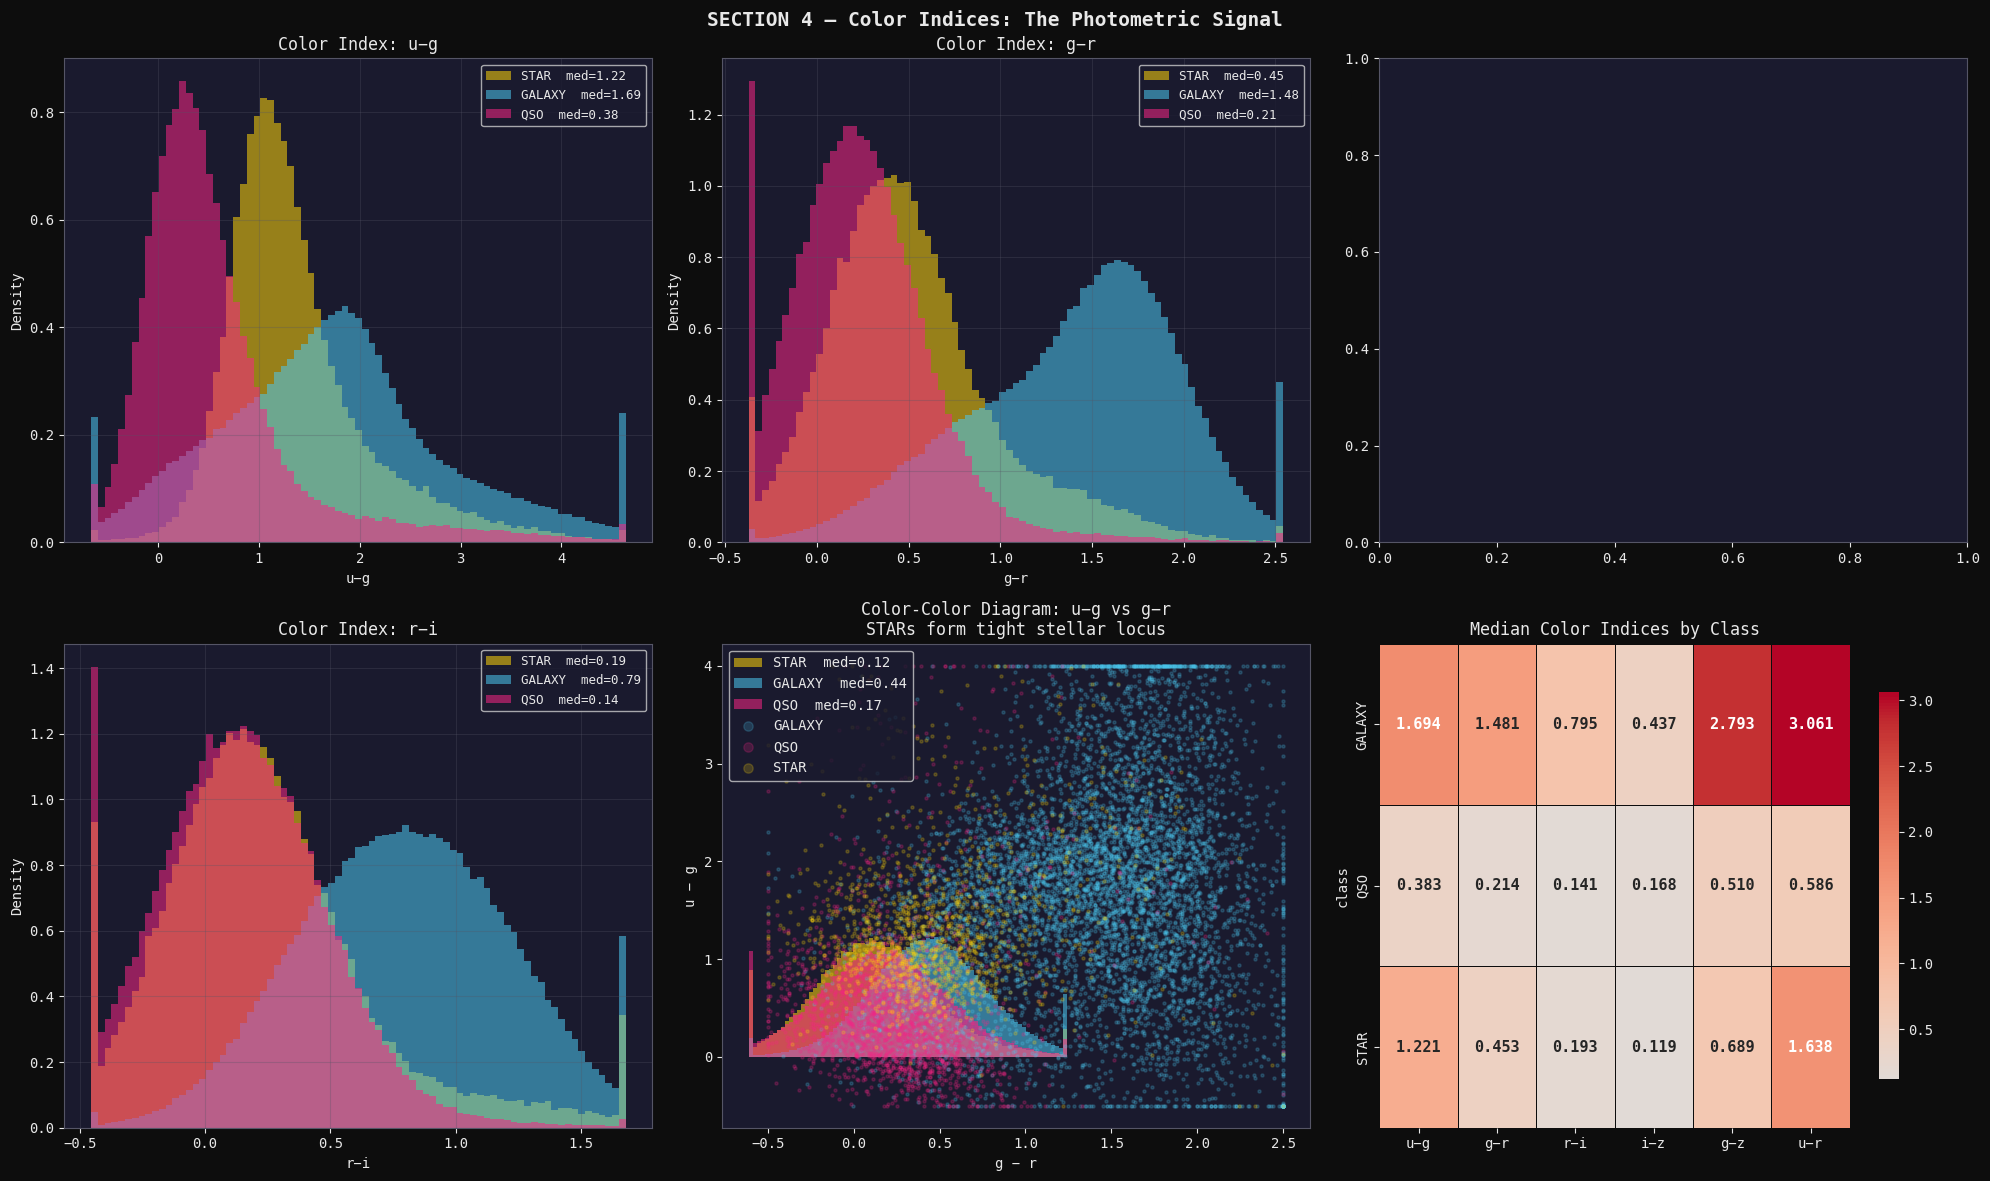

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12), facecolor=BG)
fig.suptitle('SECTION 4 — Color Indices: The Photometric Signal',
             fontsize=14, color=WHITE, fontweight='bold')

color_pairs = [('u_g','u−g'), ('g_r','g−r'), ('r_i','r−i'), ('i_z','i−z')]

for idx, (col, lbl) in enumerate(color_pairs):
    ax = axes[idx // 2, idx % 2]
    clip_lo = train[col].quantile(0.01)
    clip_hi = train[col].quantile(0.99)
    bins = np.linspace(clip_lo, clip_hi, 80)
    for cls in ['STAR', 'GALAXY', 'QSO']:
        data = train[train['class'] == cls][col].clip(clip_lo, clip_hi)
        med  = train[train['class'] == cls][col].median()
        ax.hist(data, bins=bins, density=True, alpha=0.55,
                color=CLASS_COLORS[cls], label=f'{cls}  med={med:.2f}')
    ax.set_title(f'Color Index: {lbl}', color=WHITE, fontsize=12)
    ax.set_xlabel(lbl)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.grid()

# Color-color diagram
ax5 = axes[1, 1]
sample = train.sample(10000, random_state=42)
for cls in ['GALAXY', 'QSO', 'STAR']:
    sub = sample[sample['class'] == cls]
    ax5.scatter(sub['g_r'].clip(-0.5, 2.5),
                sub['u_g'].clip(-0.5, 4.0),
                c=CLASS_COLORS[cls], alpha=0.2, s=5, label=cls)
ax5.set_title('Color-Color Diagram: u−g vs g−r\nSTARs form tight stellar locus',
              color=WHITE, fontsize=12)
ax5.set_xlabel('g − r')
ax5.set_ylabel('u − g')
ax5.legend(fontsize=10, markerscale=3)
ax5.grid()

# Median color index heatmap
ax6 = axes[1, 2]
cols_for_heat = ['u_g','g_r','r_i','i_z','g_z','u_r']
lbls_for_heat = ['u−g','g−r','r−i','i−z','g−z','u−r']
med_data = train.groupby('class')[cols_for_heat].median()
med_data.columns = lbls_for_heat
sns.heatmap(med_data, annot=True, fmt='.3f', cmap='coolwarm',
            ax=ax6, linewidths=0.5, linecolor=BG,
            annot_kws={'size': 11, 'fontweight': 'bold'},
            center=0, cbar_kws={'shrink': 0.8})
ax6.set_title('Median Color Indices by Class', color=WHITE, fontsize=12)
ax6.tick_params(colors=WHITE)

plt.tight_layout()
plt.savefig('04_color_indices.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## SThe Hard Zone: Where Classes Collide

**118,080 rows** sit in the redshift 0.05–0.25 band where STAR and GALAXY distributions heavily overlap. This is where ~11K of our model's errors concentrate. Two things separate them here:

1. **spectral_type** — within the hard zone, 43.8% of STARs are spectral type A/F vs only 7.3% of GALAXIEs
2. **Color indices** — r−i and u−g have large separating power here even when redshift fails

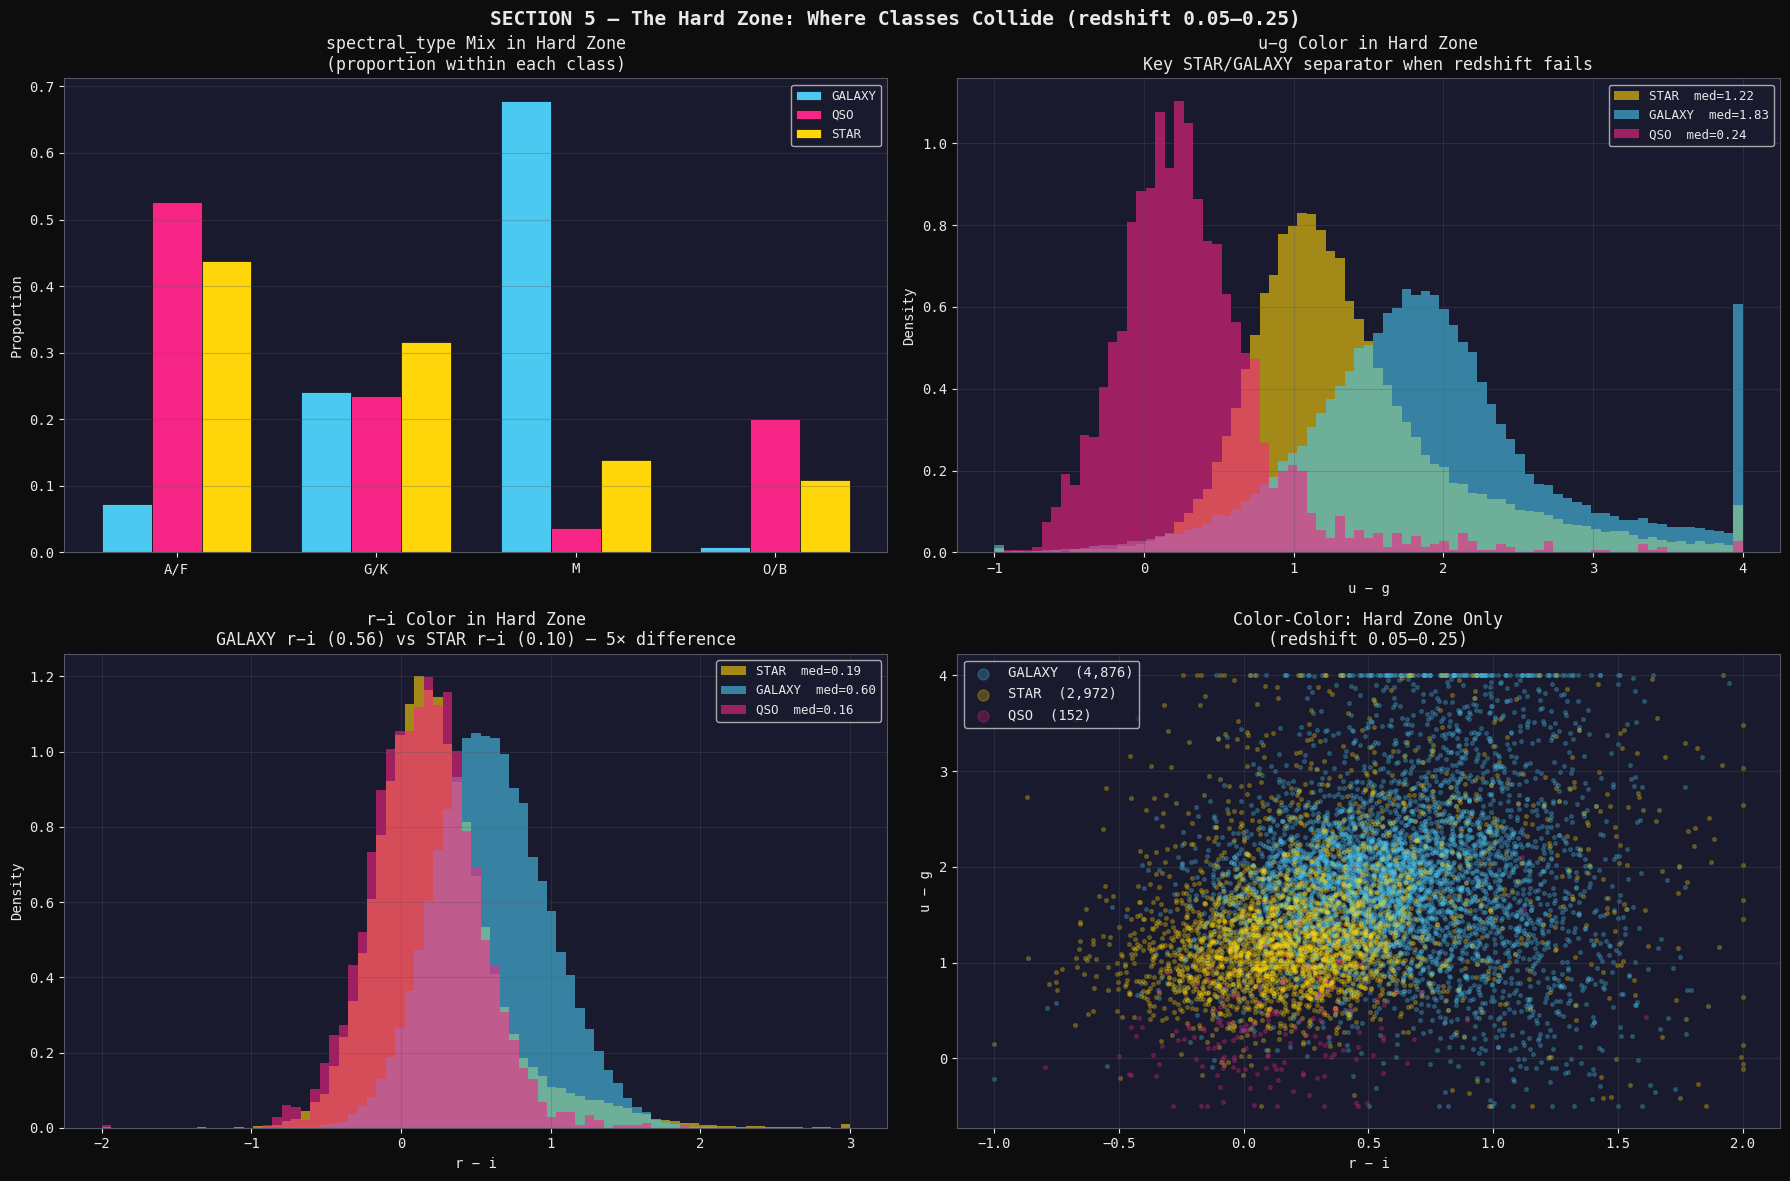

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12), facecolor=BG)
fig.suptitle('SECTION 5 — The Hard Zone: Where Classes Collide (redshift 0.05–0.25)',
             fontsize=14, color=WHITE, fontweight='bold')

overlap = train[train['redshift'].between(0.05, 0.25)].copy()

# 5a. spectral_type in hard zone by class
ax = axes[0, 0]
ct_ov = pd.crosstab(overlap['spectral_type'], overlap['class'], normalize='columns')
ct_ov = ct_ov[['GALAXY', 'QSO', 'STAR']]
x = np.arange(len(ct_ov))
width = 0.25
for i, cls in enumerate(['GALAXY', 'QSO', 'STAR']):
    bars = ax.bar(x + i*width, ct_ov[cls], width=width,
                  color=CLASS_COLORS[cls], label=cls,
                  edgecolor=BG, linewidth=0.5)
ax.set_xticks(x + width)
ax.set_xticklabels(ct_ov.index)
ax.set_title('spectral_type Mix in Hard Zone\n(proportion within each class)',
             color=WHITE, fontsize=12)
ax.set_ylabel('Proportion')
ax.legend(fontsize=9)
ax.grid(axis='y')

# 5b. u-g in hard zone
ax2 = axes[0, 1]
bins_ug = np.linspace(-1, 4, 80)
for cls in ['STAR', 'GALAXY', 'QSO']:
    data = overlap[overlap['class'] == cls]['u_g'].clip(-1, 4)
    med  = overlap[overlap['class'] == cls]['u_g'].median()
    ax2.hist(data, bins=bins_ug, density=True, alpha=0.6,
             color=CLASS_COLORS[cls], label=f'{cls}  med={med:.2f}')
ax2.set_title('u−g Color in Hard Zone\nKey STAR/GALAXY separator when redshift fails',
              color=WHITE, fontsize=12)
ax2.set_xlabel('u − g')
ax2.set_ylabel('Density')
ax2.legend(fontsize=9)
ax2.grid()

# 5c. r-i in hard zone
ax3 = axes[1, 0]
bins_ri = np.linspace(-2, 3, 80)
for cls in ['STAR', 'GALAXY', 'QSO']:
    data = overlap[overlap['class'] == cls]['r_i'].clip(-2, 3)
    med  = overlap[overlap['class'] == cls]['r_i'].median()
    ax3.hist(data, bins=bins_ri, density=True, alpha=0.6,
             color=CLASS_COLORS[cls], label=f'{cls}  med={med:.2f}')
ax3.set_title('r−i Color in Hard Zone\nGALAXY r−i (0.56) vs STAR r−i (0.10) — 5× difference',
              color=WHITE, fontsize=12)
ax3.set_xlabel('r − i')
ax3.set_ylabel('Density')
ax3.legend(fontsize=9)
ax3.grid()

# 5d. Color-color scatter hard zone only
ax4 = axes[1, 1]
samp_ov = overlap.sample(min(8000, len(overlap)), random_state=42)
for cls in ['GALAXY', 'STAR', 'QSO']:
    sub = samp_ov[samp_ov['class'] == cls]
    ax4.scatter(sub['r_i'].clip(-1, 2),
                sub['u_g'].clip(-0.5, 4),
                c=CLASS_COLORS[cls], alpha=0.25, s=7,
                label=f'{cls}  ({len(sub):,})')
ax4.set_title('Color-Color: Hard Zone Only\n(redshift 0.05–0.25)',
              color=WHITE, fontsize=12)
ax4.set_xlabel('r − i')
ax4.set_ylabel('u − g')
ax4.legend(fontsize=10, markerscale=3)
ax4.grid()

plt.tight_layout()
plt.savefig('05_hard_zone.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## Sky Coordinates: Subtle but Real Signal

`alpha` (Right Ascension) and `delta` (Declination) are the **top two features by model importance** — beating redshift. This is counterintuitive since sky position shouldn't physically determine object class.

**The explanation is SDSS survey geometry:**
- QSOs concentrate at higher declination (mean 25.8°) vs STARs (19.9°) — the survey targeted known high-redshift fields
- Train and test have **identical** coordinate distributions (KS p=0.44, p=0.90) — so this is safe signal, not a leak
- Dropping alpha/delta hurts OOF by approximately 0.01

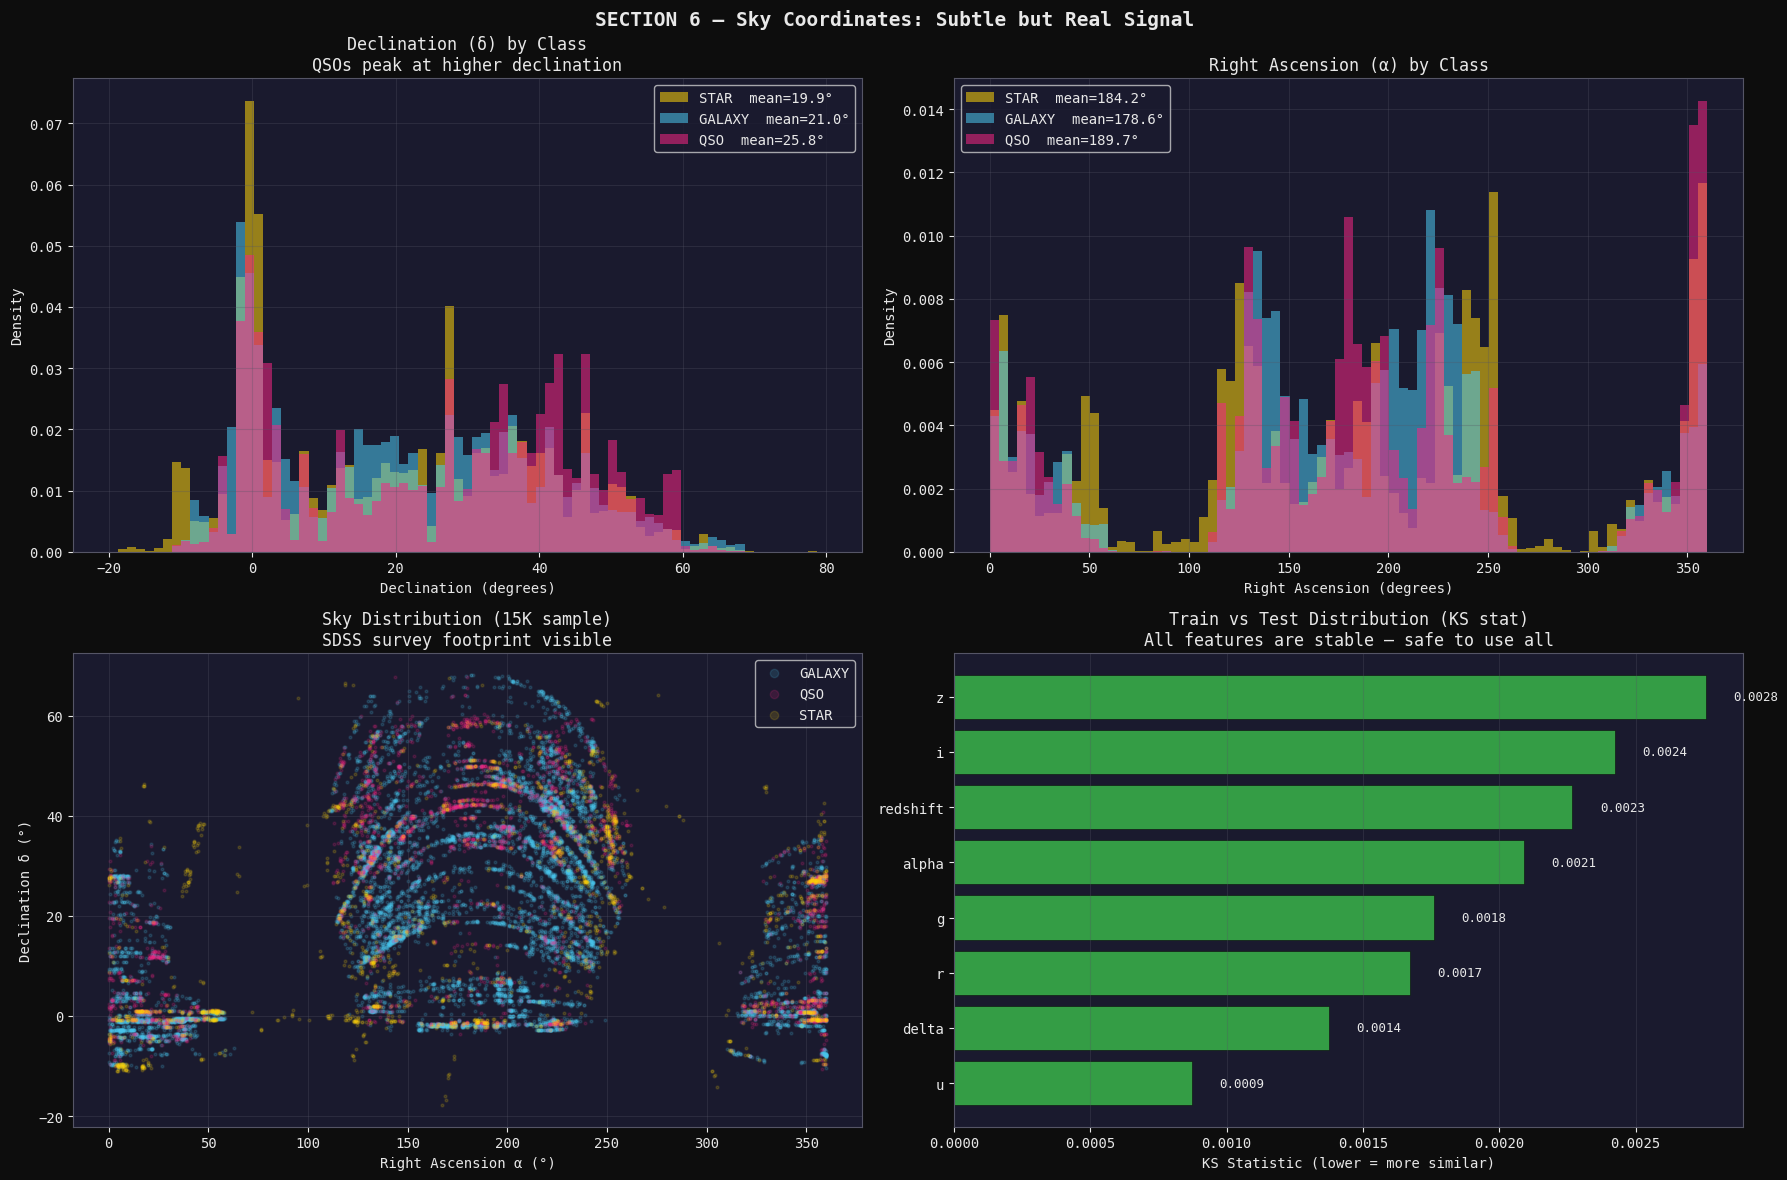

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12), facecolor=BG)
fig.suptitle('SECTION 6 — Sky Coordinates: Subtle but Real Signal',
             fontsize=14, color=WHITE, fontweight='bold')

# 6a. Delta distributions
ax = axes[0, 0]
for cls in ['STAR', 'GALAXY', 'QSO']:
    data = train[train['class'] == cls]['delta']
    ax.hist(data, bins=np.linspace(-20, 80, 80),
            density=True, alpha=0.55,
            color=CLASS_COLORS[cls],
            label=f'{cls}  mean={data.mean():.1f}°')
ax.set_title('Declination (δ) by Class\nQSOs peak at higher declination',
             color=WHITE, fontsize=12)
ax.set_xlabel('Declination (degrees)')
ax.set_ylabel('Density')
ax.legend(fontsize=10)
ax.grid()

# 6b. Alpha distributions
ax2 = axes[0, 1]
for cls in ['STAR', 'GALAXY', 'QSO']:
    data = train[train['class'] == cls]['alpha']
    ax2.hist(data, bins=np.linspace(0, 360, 80),
             density=True, alpha=0.55,
             color=CLASS_COLORS[cls],
             label=f'{cls}  mean={data.mean():.1f}°')
ax2.set_title('Right Ascension (α) by Class',
              color=WHITE, fontsize=12)
ax2.set_xlabel('Right Ascension (degrees)')
ax2.set_ylabel('Density')
ax2.legend(fontsize=10)
ax2.grid()

# 6c. Sky scatter
ax3 = axes[1, 0]
sample = train.sample(15000, random_state=42)
for cls in ['GALAXY', 'QSO', 'STAR']:
    sub = sample[sample['class'] == cls]
    ax3.scatter(sub['alpha'], sub['delta'],
                c=CLASS_COLORS[cls], alpha=0.15, s=4, label=cls)
ax3.set_title('Sky Distribution (15K sample)\nSDSS survey footprint visible',
              color=WHITE, fontsize=12)
ax3.set_xlabel('Right Ascension α (°)')
ax3.set_ylabel('Declination δ (°)')
ax3.legend(fontsize=10, markerscale=3)
ax3.grid()

# 6d. KS shift: train vs test
ax4 = axes[1, 1]
ks_results = {}
for col in ['alpha','delta','u','g','r','i','z','redshift']:
    stat, p = ks_2samp(train[col].values, test[col].values)
    ks_results[col] = {'KS': stat, 'p': p}
ks_df = pd.DataFrame(ks_results).T.sort_values('KS', ascending=True)
bar_colors = ['#39b54a' if p > 0.05 else QSO_C
              for p in ks_df['p']]
bars = ax4.barh(ks_df.index, ks_df['KS'],
                color=bar_colors, edgecolor=BG, linewidth=0.5, alpha=0.85)
for bar, val in zip(bars, ks_df['KS']):
    ax4.text(bar.get_width() + 0.0001,
             bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', color=WHITE, fontsize=9)
ax4.set_title('Train vs Test Distribution (KS stat)\nAll features are stable — safe to use all',
              color=WHITE, fontsize=12)
ax4.set_xlabel('KS Statistic (lower = more similar)')
ax4.grid(axis='x')

plt.tight_layout()
plt.savefig('06_coordinates.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## Correlation & Feature Importance

Linear correlations tell only part of the story here. `redshift` has the highest linear correlation with class (encoded numerically). But `alpha` and `delta` dominate **tree-based feature importance** — because trees capture the non-linear geographic clustering that linear correlation misses entirely.

**Key takeaway:** Don't drop features based on low linear correlation. Use tree importance as your guide.

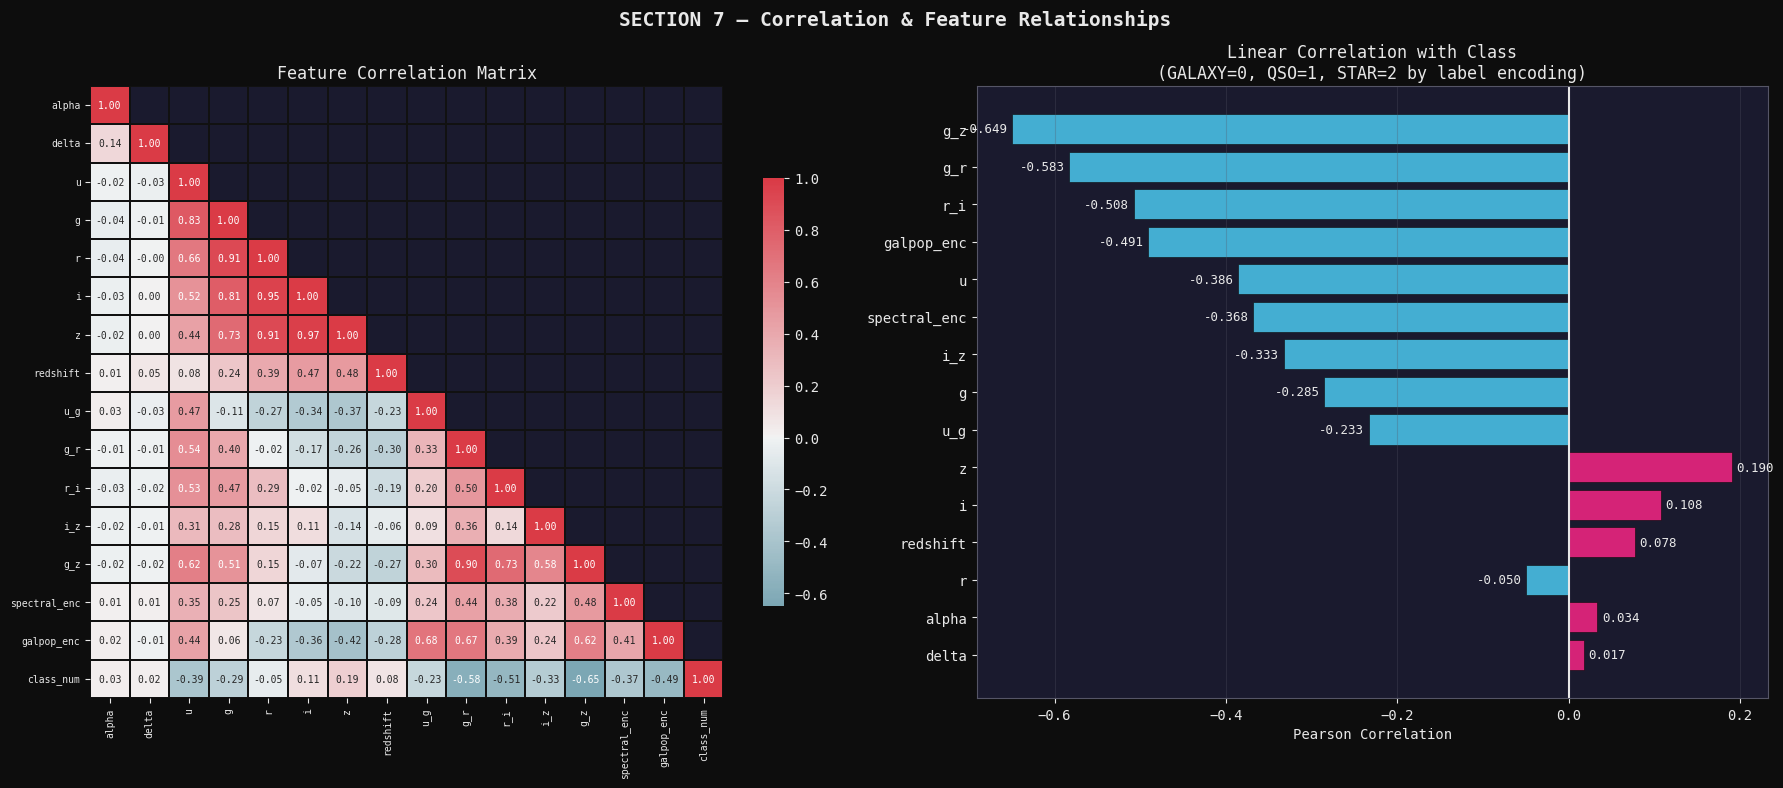

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8), facecolor=BG)
fig.suptitle('SECTION 7 — Correlation & Feature Relationships',
             fontsize=14, color=WHITE, fontweight='bold')

train_enc = train.copy()
train_enc['class_num']    = LabelEncoder().fit_transform(train_enc['class'])
train_enc['spectral_enc'] = LabelEncoder().fit_transform(train_enc['spectral_type'])
train_enc['galpop_enc']   = LabelEncoder().fit_transform(train_enc['galaxy_population'])

corr_cols = ['alpha','delta','u','g','r','i','z','redshift',
             'u_g','g_r','r_i','i_z','g_z',
             'spectral_enc','galpop_enc','class_num']
corr = train_enc[corr_cols].corr()

# 7a. Heatmap
ax = axes[0]
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap=sns.diverging_palette(220, 10, as_cmap=True),
            center=0, ax=ax, linewidths=0.3, linecolor='#111111',
            annot_kws={'size': 7},
            cbar_kws={'shrink': 0.7})
ax.set_title('Feature Correlation Matrix', color=WHITE, fontsize=12)
ax.tick_params(colors=WHITE, labelsize=7)

# 7b. Correlation with target
ax2 = axes[1]
target_corr = (corr['class_num']
               .drop('class_num')
               .sort_values(key=abs, ascending=True))
bar_clrs = [QSO_C if v > 0 else GALAXY_C for v in target_corr.values]
bars = ax2.barh(target_corr.index, target_corr.values,
                color=bar_clrs, edgecolor=BG, linewidth=0.5, alpha=0.85)
ax2.axvline(0, color=WHITE, linewidth=1.5)
for bar, val in zip(bars, target_corr.values):
    ax2.text(val + 0.005 * np.sign(val),
             bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center',
             ha='left' if val > 0 else 'right',
             color=WHITE, fontsize=9)
ax2.set_title('Linear Correlation with Class\n(GALAXY=0, QSO=1, STAR=2 by label encoding)',
              color=WHITE, fontsize=12)
ax2.set_xlabel('Pearson Correlation')
ax2.grid(axis='x')

plt.tight_layout()
plt.savefig('07_correlations.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## Photometric Magnitudes & SED Shape

The five SDSS bands from ultraviolet (u) to infrared (z) trace each object's **spectral energy distribution (SED)**. The median SED shape differs distinctly across classes — galaxies are redder, QSOs have flatter SEDs, stars follow the stellar main sequence.

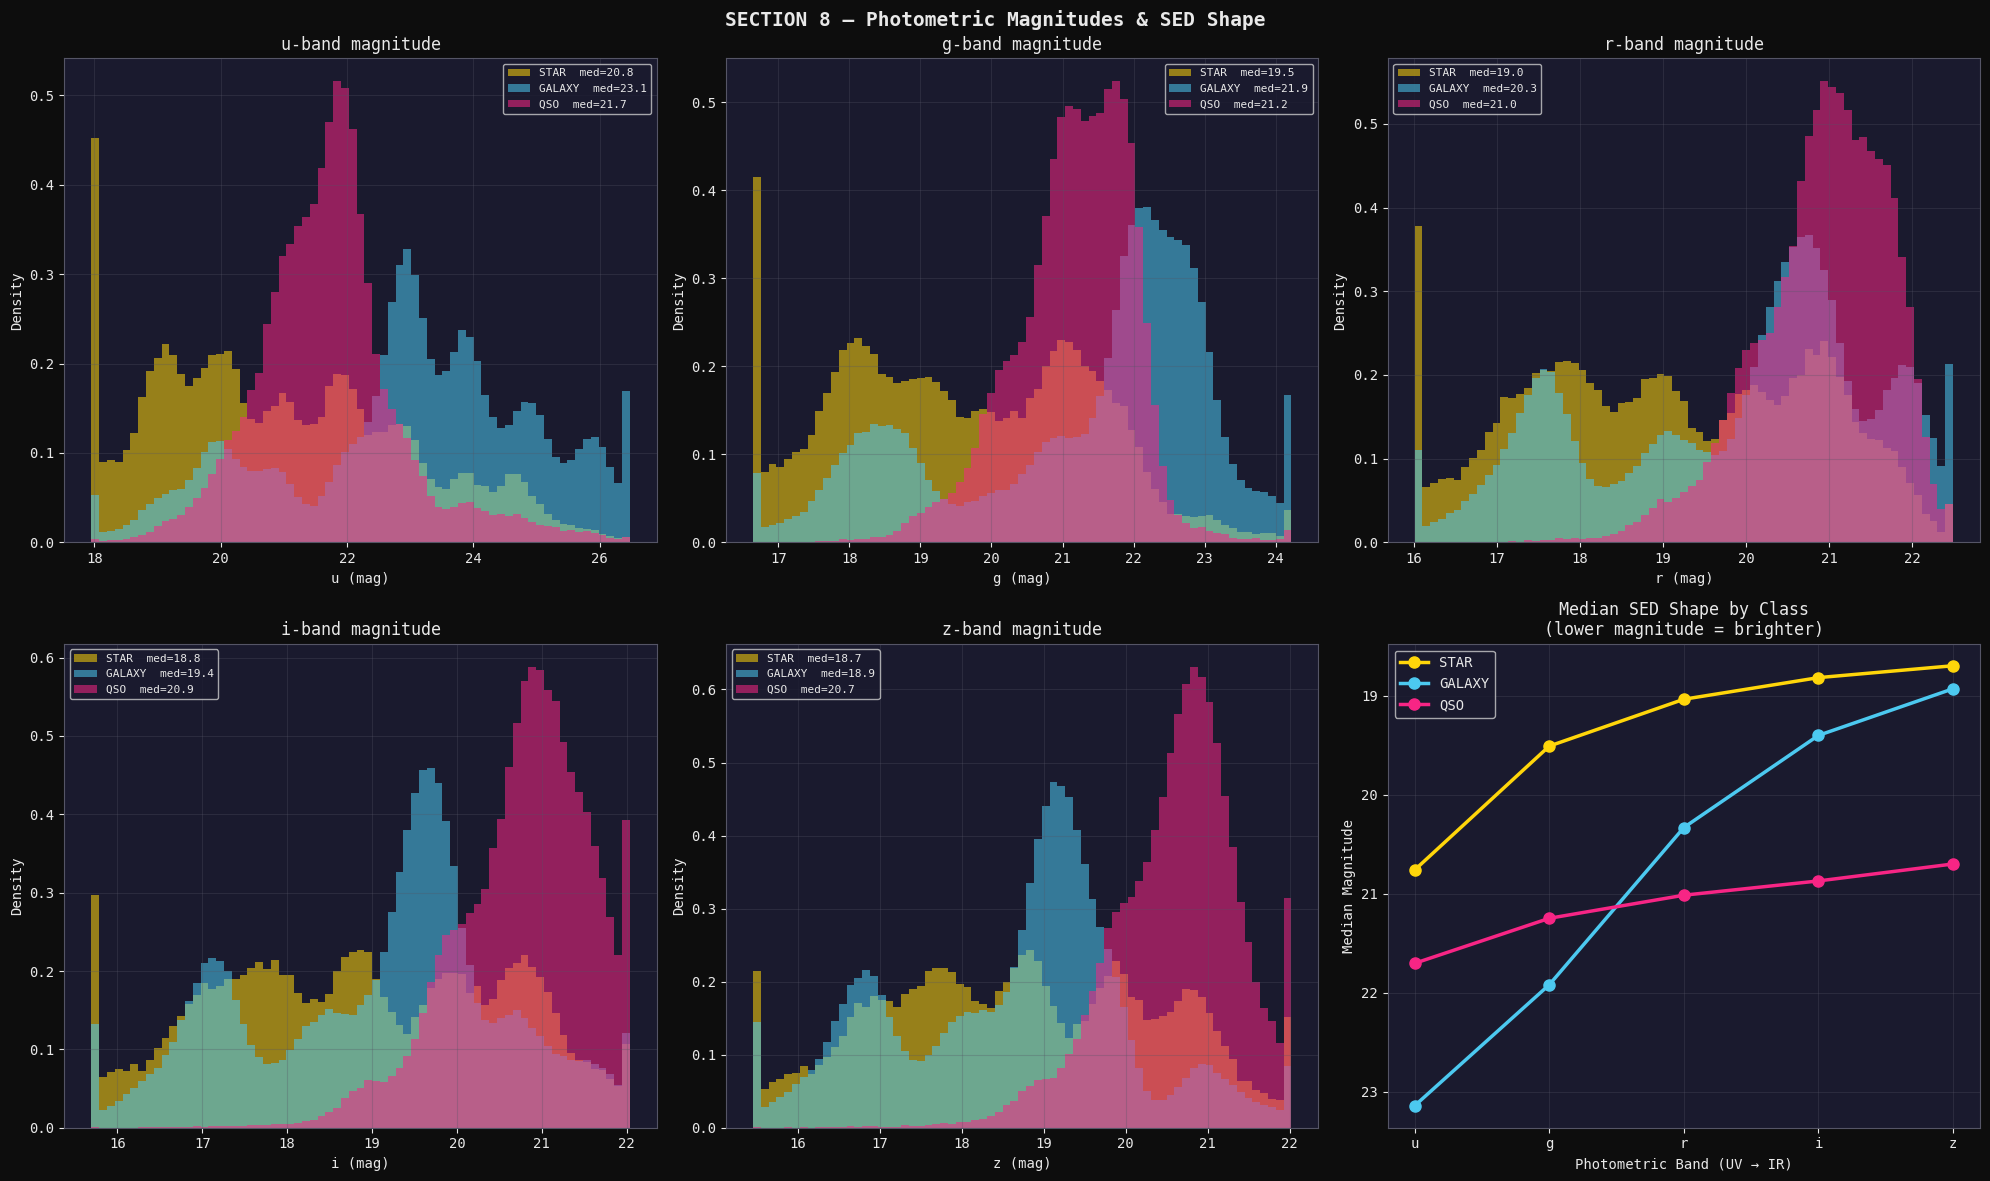

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12), facecolor=BG)
fig.suptitle('SECTION 8 — Photometric Magnitudes & SED Shape',
             fontsize=14, color=WHITE, fontweight='bold')

bands = ['u', 'g', 'r', 'i', 'z']

for idx, band in enumerate(bands):
    ax = axes[idx // 3, idx % 3]
    clip_lo = train[band].quantile(0.01)
    clip_hi = train[band].quantile(0.99)
    bins = np.linspace(clip_lo, clip_hi, 70)
    for cls in ['STAR', 'GALAXY', 'QSO']:
        data = train[train['class'] == cls][band].clip(clip_lo, clip_hi)
        med  = train[train['class'] == cls][band].median()
        ax.hist(data, bins=bins, density=True, alpha=0.55,
                color=CLASS_COLORS[cls], label=f'{cls}  med={med:.1f}')
    ax.set_title(f'{band}-band magnitude', color=WHITE, fontsize=12)
    ax.set_xlabel(f'{band} (mag)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid()

# SED shape
ax6 = axes[1, 2]
band_positions = np.arange(len(bands))
for cls in ['STAR', 'GALAXY', 'QSO']:
    meds = [train[train['class'] == cls][b].median() for b in bands]
    ax6.plot(band_positions, meds,
             color=CLASS_COLORS[cls], linewidth=2.5,
             marker='o', markersize=8, label=cls)
ax6.set_xticks(band_positions)
ax6.set_xticklabels(bands)
ax6.set_title('Median SED Shape by Class\n(lower magnitude = brighter)',
              color=WHITE, fontsize=12)
ax6.set_xlabel('Photometric Band (UV → IR)')
ax6.set_ylabel('Median Magnitude')
ax6.legend(fontsize=10)
ax6.invert_yaxis()
ax6.grid()

plt.tight_layout()
plt.savefig('08_magnitudes.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## Summary — What Actually Classifies a Star, Galaxy, or QSO?

After a full analysis of 577K SDSS observations, the classification problem has a clear 3-layer structure:
**redshift → synthetic categoricals → color indices**. Here are the 5 things the data actually says that aren't obvious from a first look.

---

### 🔴 1 — `spectral_type` × `galaxy_population` combos are only 37–95% pure — not a free pass

M×Red_Sequence is 95% GALAXY and O/B×Blue_Cloud is 72% QSO — nearly deterministic.
But **A/F and G/K combos** covering 40% of the data are only **37–52% pure**.
For those rows, redshift and color indices must do the real work.

---

### 🔴 2 — `redshift` is the dominant separator — but 25.9% of STARs fall in galaxy territory

74% of STARs have redshift < 0.10, making them trivially easy.
The hard **25.9% (21,448 STARs)** with redshift > 0.10 cause most model errors.
**118K rows** in the 0.05–0.25 zone are a genuine classification challenge.

---

### 🟡 3 — `galaxy_population` has near-zero model importance (56) despite being a strong raw signal

Red_Sequence is 90% GALAXY regardless of spectral type — looks powerful in isolation.
But once `spectral_type` is encoded, `galaxy_population` adds nothing new.
The `st_gp` interaction feature (importance 373) captures all its signal redundantly.

---

### 🟡 4 — `alpha` & `delta` are the top 2 model features — SDSS survey geometry, not a data leak

QSOs concentrate at higher declination (mean **25.8°**) vs STARs (**19.9°**).
Train and test distributions are identical — KS p-values of **0.44** and **0.90**.
Dropping coordinates costs ~0.01 OOF balanced accuracy. **Keep them.**

---

### 🟢 5 — Color indices rescue the hard zone where redshift alone fails

Within redshift 0.05–0.25: GALAXY r−i median = **0.56** vs STAR = **0.10** — a **5× gap**.
The classic stellar locus in u−g vs g−r space separates STARs from GALAXIEs cleanly.
Engineering color indices is the **single most impactful feature step** in this competition.

---

*If this was useful, please consider upvoting 🙌*